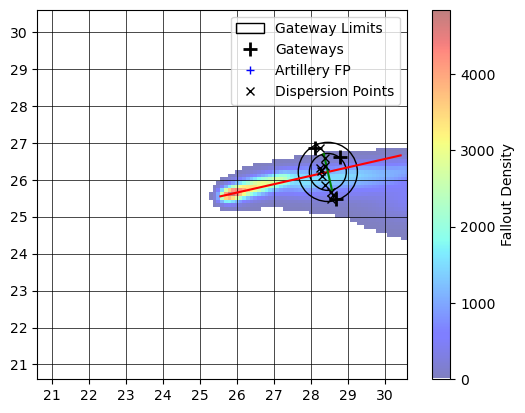

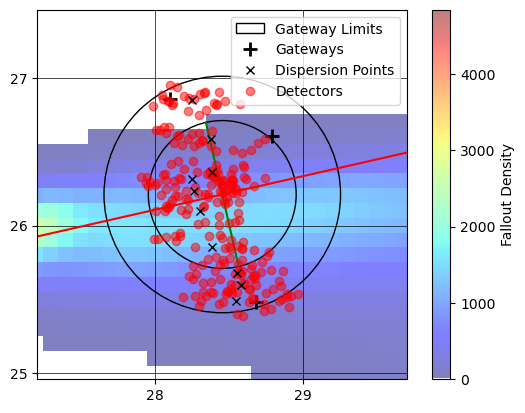

In [1]:
from genDataFromDelfic import getSCRAMfield

radField, gateways, detectors = getSCRAMfield(plot=True, numArtyShells=10)


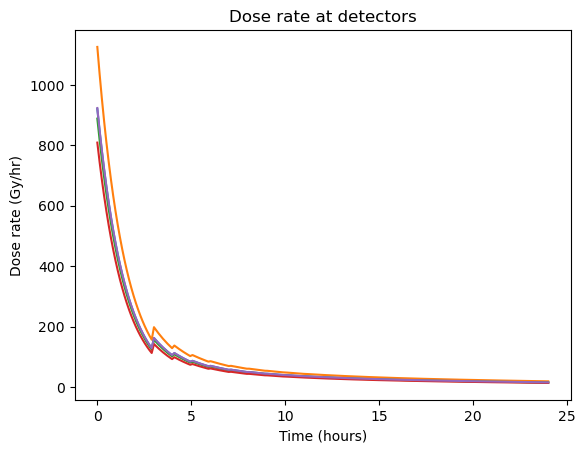

In [2]:
import numpy as np

timesToPlot = np.linspace(0, 24, 200)

import matplotlib.pyplot as plt

plt.figure()
for detector in detectors[:5]:
  doseRates = []
  for time in timesToPlot:
    dose = detector.getTrueDoseRate(time)
    doseRates.append(dose)
  plt.plot(timesToPlot, doseRates)

plt.xlabel('Time (hours)')
plt.ylabel('Dose rate (Gy/hr)')
plt.title('Dose rate at detectors')
plt.show()

In [3]:
def updateDetector(detector, gateways, timesteps):
  for t in timesteps:
    #TODO: add in the ability for gateways to not be present
    detector.updateSim(t, gateways)
  return detector

timesToPlot = np.linspace(0, 24, 50)
for i, detector in enumerate(detectors):
  detectors[i] = updateDetector(detector, gateways, timesToPlot)


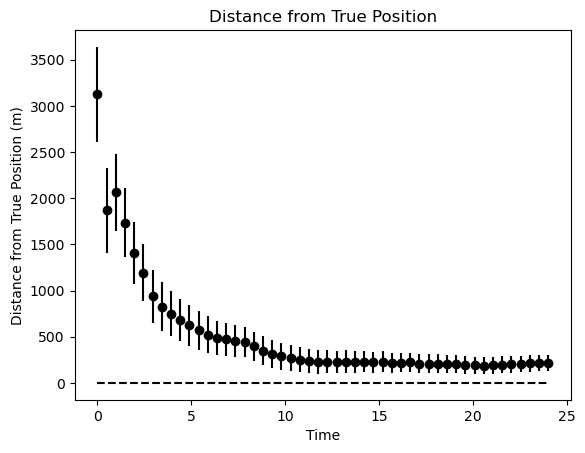

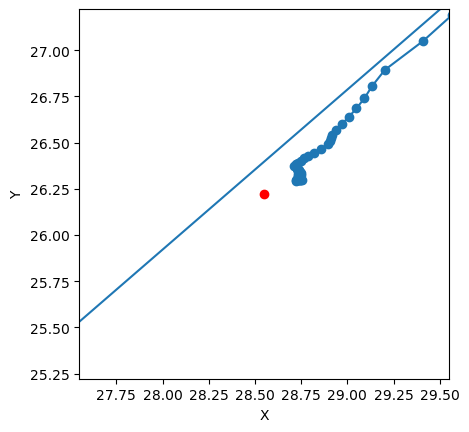

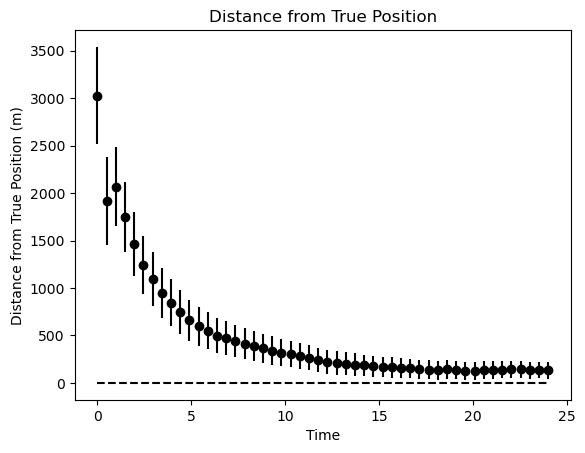

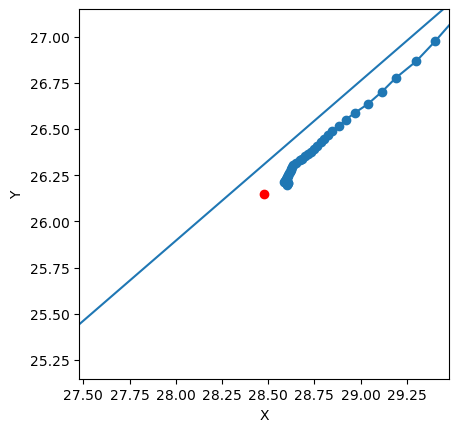

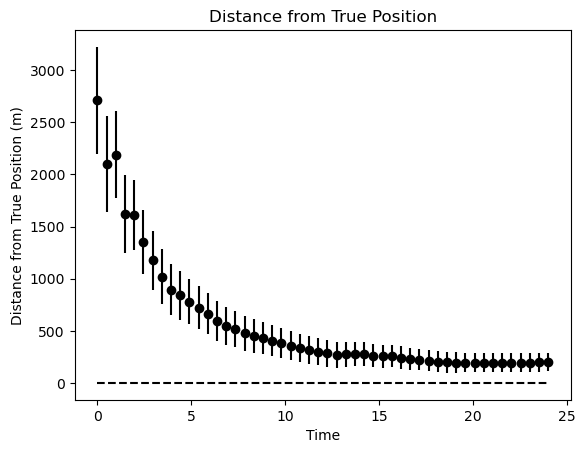

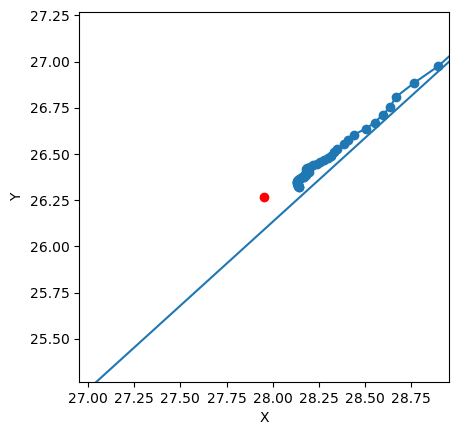

In [4]:
## confirm the results by plotting the dose rate and position estimates for a single detector

for det in detectors[:3]:
    #plot the dose rate and position estimates for a single detector
    det.plotDistanceError(det.trueX, det.trueY)
    
    #plot the series of predicted positions for a single detector
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(det.predictedX, det.predictedY, 'o-')
    ax.plot(det.trueX, det.trueY, 'ro')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_xlim(det.trueX-1, det.trueX+1)
    ax.set_ylim(det.trueY-1, det.trueY+1)
    ax.set_aspect('equal')
    plt.show()